In [2]:
#importing necessary libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cv2
import shutil
from tqdm import tqdm
import os
!pip install onnxruntime

In [3]:
! pip install rembg -q

**Extracting the contents of a zip archive using Python's `zipfile` library.**

In [4]:
import zipfile


with zipfile.ZipFile('/kaggle/input/platesv2/plates.zip', 'r') as zip_obj:
   # Extract all the contents of zip file in current directory
   zip_obj.extractall('/kaggle/working/')

**Setting the variable data_root to the directory path /kaggle/working/plates/**

In [5]:
data_root = '/kaggle/working/plates/'

In [6]:
from pathlib import Path
from rembg import remove, new_session

* First, I created two folders (train and val) inside the /kaggle/working/plates/ directory for both "cleaned" and "dirty" labels (using os.makedirs).
* I'm looping through all JPEG images in the /kaggle/working/plates/train/cleaned and /kaggle/working/plates/train/dirty folders. For each image, I'm using a function called remove (presumably for noise removal) with a session object (session) to process it.
* Every fifth image is then copied to the corresponding validation folder (/kaggle/working/val/) while the rest stay in the training folder (/kaggle/working/train/). I'm keeping the same filename (using .stem) but changing the destination path.

In [7]:
session = new_session()

labels = ['cleaned', 'dirty']

for dir_name in ['train', 'val']:
    for l in labels:
        os.makedirs(os.path.join(dir_name, l), exist_ok=True)

for l in labels:
    for i, file in enumerate(tqdm(Path(f"/kaggle/working/plates/train/{l}").glob('*.jpg'))):
        input_path = str(file)
        if i % 5 == 0:
            output_path = f"/kaggle/working/val/{l}/{file.stem}.jpg"
        else:
            output_path = f"/kaggle/working/train/{l}/{file.stem}.jpg"
        with open(input_path, 'rb') as i:
            with open(output_path, 'wb') as o:
                input = i.read()
                output = remove(input, session=session)
                o.write(output)

100%|████████████████████████████████████████| 176M/176M [00:00<00:00, 256GB/s]
20it [00:12,  1.66it/s]
20it [00:12,  1.64it/s]


I'm creating a folder named "unknown" inside "test" and then processing all JPEGs in the "/kaggle/working/plates/test" folder using the remove function (with a session) before saving them in the "unknown" folder.

In [8]:
os.makedirs("test/unknown", exist_ok=True)

session = new_session()

for i, file in enumerate(tqdm(Path("/kaggle/working/plates/test").glob('*.jpg'))):
        input_path = str(file)
        output_path = f"/kaggle/working/test/unknown/{file.stem}.jpg"
        with open(input_path, 'rb') as i:
            with open(output_path, 'wb') as o:
                input = i.read()
                output = remove(input, session=session)
                o.write(output)

744it [08:31,  1.45it/s]


Next, I'm setting up data augmentation for my training data using ImageDataGenerator, applying random rotations, shifts, zooms, and flips. Then, I'm creating data generators for both training and validation sets, resizing images to 224x224 and using a batch size of 24 for training and 8 for validation.

In [9]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator


train_datagen=ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip = True
        )

train_ds = train_datagen.flow_from_directory(
        "./train",
        target_size=(224, 224),
        keep_aspect_ratio=True,
        batch_size=24,
        class_mode='binary',
        shuffle=True)

val_datagen = ImageDataGenerator()

val_ds = val_datagen.flow_from_directory(
        "./val",
        target_size=(224, 224),
        keep_aspect_ratio=True,
        batch_size=8,
        class_mode='binary',
        shuffle=False)

2024-12-30 08:47:01.627402: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-30 08:47:01.627548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-30 08:47:01.763287: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 32 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


In [10]:
import matplotlib.pyplot as plt


def get_image_and_label_batch(dataset, n, labels=None):
    plt.figure(figsize=(3 * min(n, 8), 4 * (n // 8 + 1)))
    if labels is None:
        images, labels = next(dataset)
    else:
        images, _ = next(dataset)
    for i, (img, l) in enumerate(zip(images[:n], labels[:n])):
        ax = plt.subplot(n // 8 + 1, min(n, 8), i + 1)
        plt.imshow(img.astype('uint8'))
        plt.title(l)
        plt.axis("off")

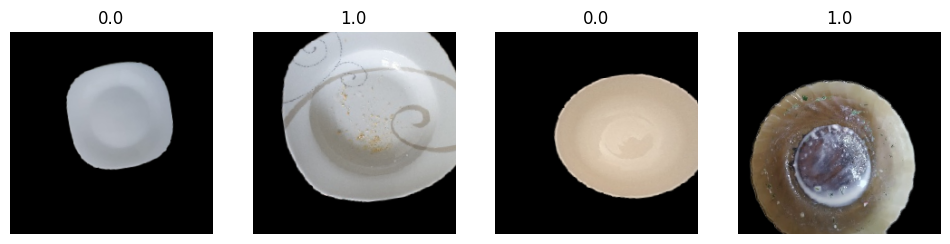

In [11]:
get_image_and_label_batch(train_ds, 4)

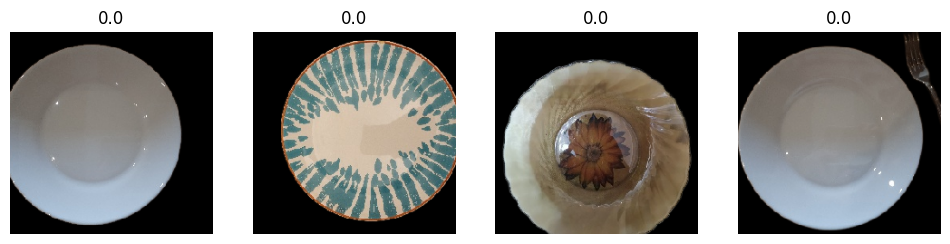

In [12]:
get_image_and_label_batch(val_ds, 4)

Next, I'm loading a pre-trained **ResNet152** model from Keras, excluding its top classification layer and freezing its weights to use it as a feature extractor. Then, I'm building a new model on top of this base, adding a global average pooling layer, a dense layer, dropout for regularization, and a final sigmoid output layer for binary classification.

In [13]:
import keras


base_model = keras.applications.ResNet152(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(224, 224, 3),
    include_top=False,  # Do not include the ImageNet classifier at the top.
)

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(224, 224, 3))

# specific ResNet preprocessing
x = keras.applications.resnet.preprocess_input(inputs)

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(400, activation='relu')(x)
x = keras.layers.Dropout(0.25)(x)  # Regularize with dropout
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(loss='binary_crossentropy', 
              optimizer = keras.optimizers.Adam(learning_rate=0.0003, amsgrad=True), 
              metrics=['binary_accuracy'])

model.summary()

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet152           │ (None, 7, 7,      │ 58,370,944 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet152[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 400)       │    819,600 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 400)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        401 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 59,190,945 (225.80 MB)

 Trainable params: 820,001 (3.13 MB)

 Non-trainable params: 58,370,944 (222.67 MB)

In [14]:
from tensorflow.python.keras.callbacks import EarlyStopping

cb_early_stopper = EarlyStopping(monitor = 'val_loss', patience = 7)

#Training Model
hist = model.fit(train_ds,
          validation_data=val_ds,
          epochs=200,
          callbacks=[cb_early_stopper])

Epoch 1/200


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/2 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - binary_accuracy: 0.6250 - loss: 0.5680

I0000 00:00:1735548467.039992     155 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1735548467.136982     155 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - binary_accuracy: 0.5469 - loss: 0.7757 

W0000 00:00:1735548479.685258     155 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


2/2 ━━━━━━━━━━━━━━━━━━━━ 51s 22s/step - binary_accuracy: 0.5208 - loss: 0.8450 - val_binary_accuracy: 0.7500 - val_loss: 0.5225
Epoch 2/200


W0000 00:00:1735548489.069027     155 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - binary_accuracy: 0.5903 - loss: 0.6669 - val_binary_accuracy: 0.7500 - val_loss: 0.5275
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - binary_accuracy: 0.7917 - loss: 0.3682 - val_binary_accuracy: 0.7500 - val_loss: 0.5531
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - binary_accuracy: 0.9792 - loss: 0.1918 - val_binary_accuracy: 0.6250 - val_loss: 0.5682
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - binary_accuracy: 0.9375 - loss: 0.1507 - val_binary_accuracy: 0.7500 - val_loss: 0.6462
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - binary_accuracy: 1.0000 - loss: 0.0884 - val_binary_accuracy: 0.6250 - val_loss: 0.7497
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - binary_accuracy: 1.0000 - loss: 0.0853 - val_binary_accuracy: 0.6250 - val_loss: 0.8142
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - binary_accuracy: 0.9375 - loss: 0.1065 - val_binary_accuracy: 0.6250 - val_loss: 0.8612


<Axes: >

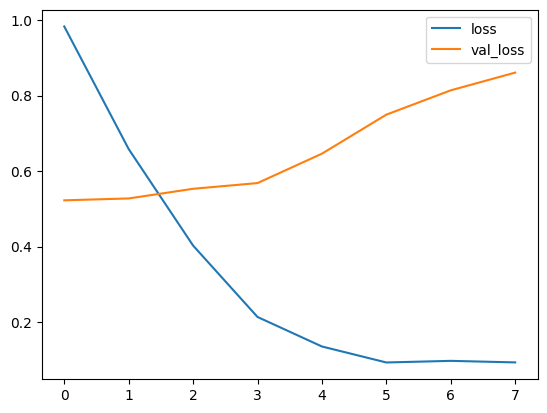

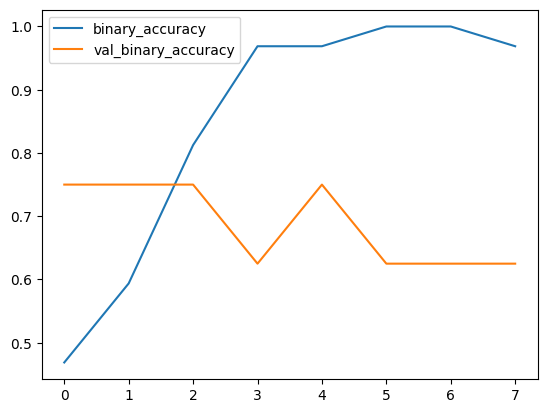

In [15]:
history_frame = pd.DataFrame(hist.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot()

In [16]:
shutil.copytree('plates/test', 'test/unknown', dirs_exist_ok=True)

'test/unknown'

In [17]:
# creating a data generator for test set using ImageDataGenerator
test_datagen = ImageDataGenerator()
test_ds = test_datagen.flow_from_directory(
        './test',
        target_size=(224, 224),
        keep_aspect_ratio=True,
        batch_size=32,
        shuffle=False)

Found 744 images belonging to 1 classes.


In [18]:
test_ds.reset()
#Predicting the model outcome on test_ds
preds = model.predict(test_ds, verbose=True)

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/24 ━━━━━━━━━━━━━━━━━━━━ 5:40 15s/step

W0000 00:00:1735548509.714865     155 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 598ms/step


W0000 00:00:1735548523.473381     156 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [19]:
preds[:10]

array([[0.9922926 ],
       [0.8330871 ],
       [0.9849838 ],
       [0.99663746],
       [0.99751484],
       [0.9998337 ],
       [0.99336433],
       [0.99050504],
       [0.993324  ],
       [0.9863901 ]], dtype=float32)

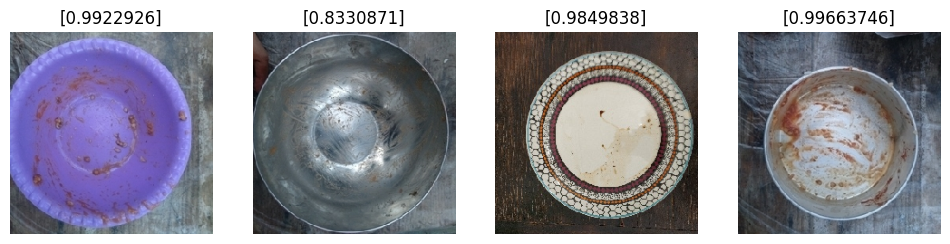

In [20]:
test_ds.reset()
get_image_and_label_batch(test_ds, 4, labels=preds)

In [21]:
labels = ['dirty' if x > 0.5 else 'cleaned' for x in preds]
labels[:8]

['dirty', 'dirty', 'dirty', 'dirty', 'dirty', 'dirty', 'dirty', 'dirty']

In [22]:
#Creating a dataframe that can store the final result using the sample_submission.csv
submission_df = pd.read_csv('/kaggle/input/platesv2/sample_submission.csv')

In [23]:
#Replacing the sample label values with generated label values
submission_df['label'] = labels

In [24]:
#Printing the final dataframe for observation/study
submission_df

,id,label
0,0,dirty
1,1,dirty
2,2,dirty
3,3,dirty
4,4,dirty
...,...,...
739,739,dirty
740,740,dirty
741,741,cleaned
742,742,dirty


In [25]:
#Submitting the final outcome
submission_df.to_csv('submission.csv', index=False)

**Removing the directories train, val, test, and plates recursively and forcefully to cleanup the disk space.**

In [26]:
!rm -rf train val test plates

**Conclusion:**

An accuracy score of 0.87096 is achieved on Test Dataset using ResNet152 as base model. There is still scope to improve this accuracy score using more advanced image classification algorithm as base model.